<a href="https://colab.research.google.com/github/YAPrada/MALDI-Data-Preeclampsia/blob/main/Nanocluster_Leismania.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install pandas

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import mannwhitneyu
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    balanced_accuracy_score,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay,
)
from sklearn.model_selection import LeaveOneGroupOut, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", context="notebook")
RANDOM_STATE = 42


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import glob

glob.glob(
    "/content/drive/MyDrive/**/datos_normalizados_sin_duplicado.txt",
    recursive=True
)

['/content/drive/MyDrive/Data Analisis/datos_sin_duplicado/datos_normalizados_sin_duplicado.txt']

In [ ]:
RUTA = "/content/drive/MyDrive/Data Analisis/datos_sin_duplicado/datos_normalizados_sin_duplicado.txt"

In [ ]:
df = pd.read_csv(RUTA, sep="\t")

print("Dimensiones:", df.shape)
display(df.head())
display(df["dataset_id"].value_counts())

Dimensiones: (12031, 27)


,source_file,source_sheet,dataset_id,experiment_group,measurement_type,matrix,nanomaterial,analyte,sample_label_original,sample_id,...,excitation_nm,emission_nm,intensity_original,intensity,intensity_scaled_max,intensity_minmax,intensity_zscore,quality_flag,is_duplicate_dataset,include_primary_analysis
0,Datos Au2854_Estabilidad buffer.xlsx,Au2854_Sueros,serum_au2854_ex330,serum_health_status,fluorescence_emission_spectrum,serum,Au2854,NaN,A2R2 Inf,A2R2,...,330.0,450.0,7037.486,7037.48600,1.000000,1.000000,3.009932,ok,False,True
1,Datos Au2854_Estabilidad buffer.xlsx,Au2854_Sueros,serum_au2854_ex330,serum_health_status,fluorescence_emission_spectrum,serum,Au2854,NaN,A2R2 Inf,A2R2,...,330.0,451.0,6932.11768,6932.11768,0.985028,0.984520,2.943956,ok,False,True
2,Datos Au2854_Estabilidad buffer.xlsx,Au2854_Sueros,serum_au2854_ex330,serum_health_status,fluorescence_emission_spectrum,serum,Au2854,NaN,A2R2 Inf,A2R2,...,330.0,452.0,6869.52734,6869.52734,0.976134,0.975325,2.904765,ok,False,True
3,Datos Au2854_Estabilidad buffer.xlsx,Au2854_Sueros,serum_au2854_ex330,serum_health_status,fluorescence_emission_spectrum,serum,Au2854,NaN,A2R2 Inf,A2R2,...,330.0,453.0,6808.762,6808.76200,0.967499,0.966398,2.866717,ok,False,True
4,Datos Au2854_Estabilidad buffer.xlsx,Au2854_Sueros,serum_au2854_ex330,serum_health_status,fluorescence_emission_spectrum,serum,Au2854,NaN,A2R2 Inf,A2R2,...,330.0,454.0,6680.09375,6680.09375,0.949216,0.947495,2.786152,ok,False,True


,count
dataset_id,
serum_au2854_ex330,3250
leishmania_serum_au2854,2442
buffer_au2854_sap,2250
leishmania_serum_aubsa2854,2109
blank_serum_eem,1980


In [ ]:
DATASETS = [
    "serum_au2854_ex330",
    "leishmania_serum_au2854",
    "leishmania_serum_aubsa2854",
]

analysis = df[
    df["dataset_id"].isin(DATASETS)
    & df["biological_group"].isin(["infected", "non_infected"])
    & df["intensity"].notna()
].copy()

# La combinación incluye el grupo porque algunos identificadores se reutilizan.
analysis["biological_sample"] = (
    analysis["dataset_id"].astype(str)
    + "__"
    + analysis["biological_group"].astype(str)
    + "__"
    + analysis["sample_id"].astype(str)
)

sample_counts = (
    analysis.groupby(["dataset_id", "biological_group"], observed=True)
    .agg(
        biological_samples=("biological_sample", "nunique"),
        technical_spectra=("sample_unique", "nunique"),
        wavelengths=("emission_nm", "nunique"),
    )
    .reset_index()
)
display(sample_counts)


,dataset_id,biological_group,biological_samples,technical_spectra,wavelengths
0,leishmania_serum_au2854,infected,5,10,111
1,leishmania_serum_au2854,non_infected,4,10,111
2,leishmania_serum_aubsa2854,infected,5,10,111
3,leishmania_serum_aubsa2854,non_infected,3,7,111
4,serum_au2854_ex330,infected,6,6,250
5,serum_au2854_ex330,non_infected,6,6,250


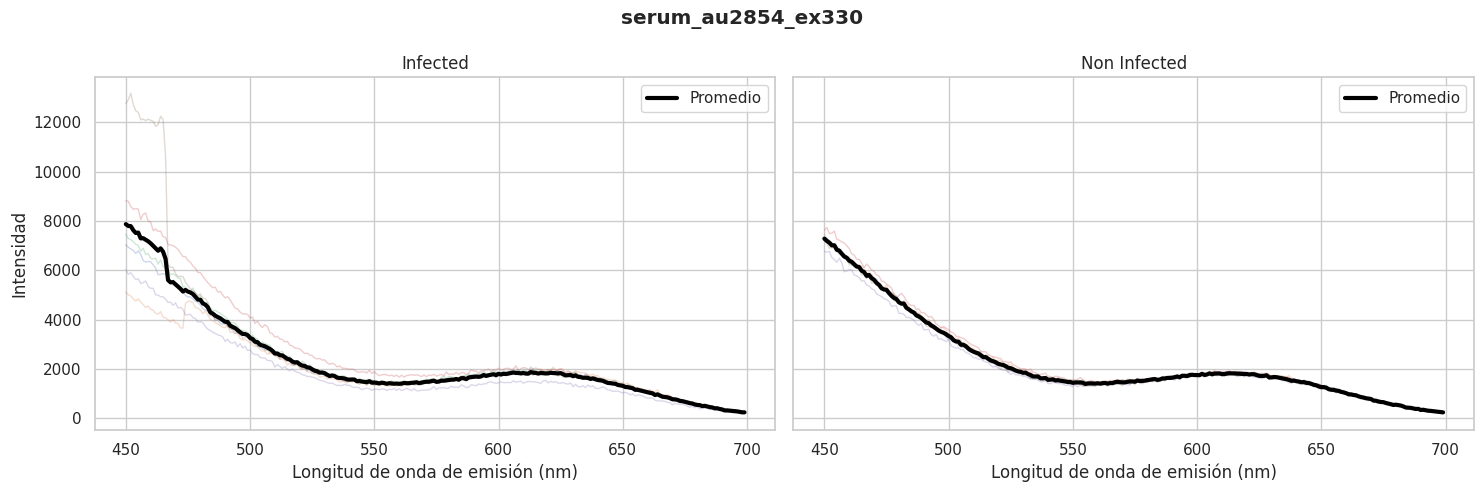

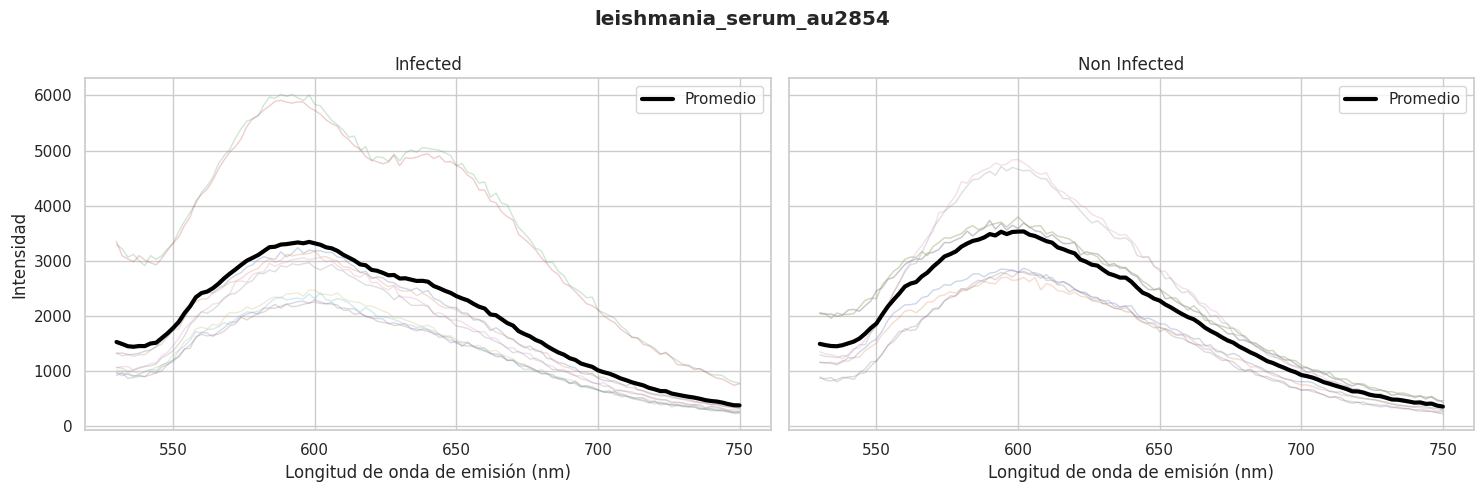

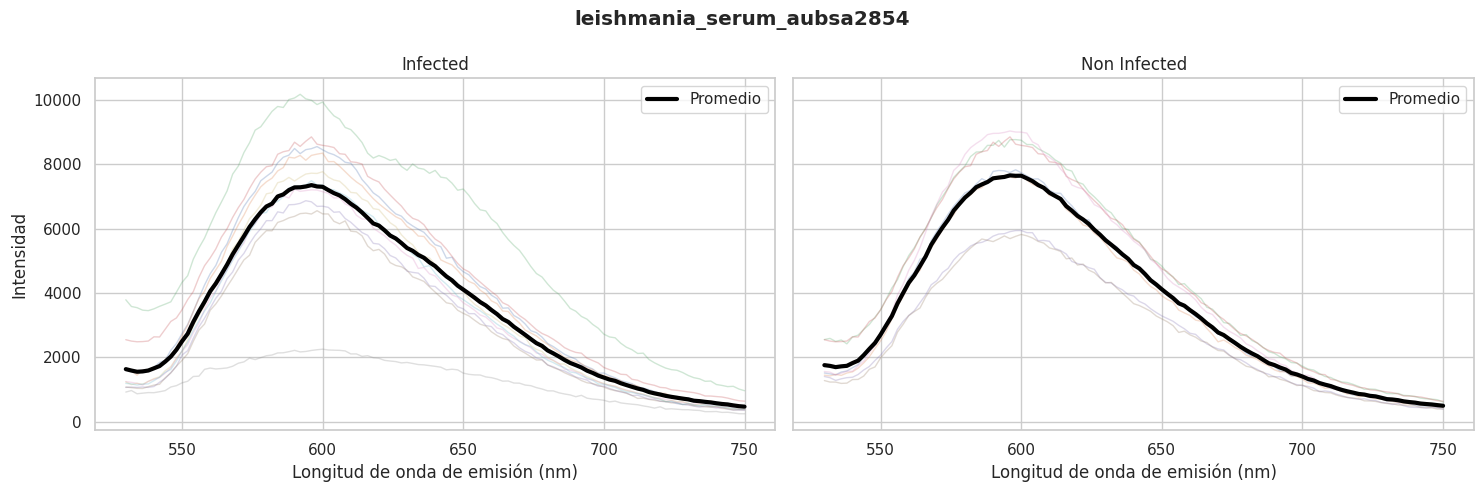

In [ ]:
def plot_raw_spectra(data, dataset_id):
    subset = data[data["dataset_id"] == dataset_id].copy()
    fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

    for ax, group in zip(axes, ["infected", "non_infected"]):
        group_data = subset[subset["biological_group"] == group]

        for _, spectrum in group_data.groupby("sample_unique"):
            spectrum = spectrum.sort_values("emission_nm")
            ax.plot(
                spectrum["emission_nm"],
                spectrum["intensity"],
                alpha=0.28,
                linewidth=1,
            )

        mean_curve = (
            group_data.groupby("emission_nm", as_index=False)["intensity"].mean()
        )
        ax.plot(
            mean_curve["emission_nm"],
            mean_curve["intensity"],
            color="black",
            linewidth=3,
            label="Promedio",
        )
        ax.set_title(group.replace("_", " ").title())
        ax.set_xlabel("Longitud de onda de emisión (nm)")
        ax.legend()

    axes[0].set_ylabel("Intensidad")
    fig.suptitle(dataset_id, fontweight="bold")
    plt.tight_layout()
    plt.show()


for dataset in DATASETS:
    plot_raw_spectra(analysis, dataset)


In [ ]:
biological_spectra = (
    analysis.groupby(
        [
            "dataset_id",
            "biological_group",
            "biological_sample",
            "sample_id",
            "emission_nm",
        ],
        as_index=False,
        observed=True,
    )["intensity"]
    .mean()
)

display(biological_spectra.head())


,dataset_id,biological_group,biological_sample,sample_id,emission_nm,intensity
0,leishmania_serum_au2854,infected,leishmania_serum_au2854__infected__IS1,IS1,530.0,940.726654
1,leishmania_serum_au2854,infected,leishmania_serum_au2854__infected__IS1,IS1,532.0,940.283631
2,leishmania_serum_au2854,infected,leishmania_serum_au2854__infected__IS1,IS1,534.0,908.378600
3,leishmania_serum_au2854,infected,leishmania_serum_au2854__infected__IS1,IS1,536.0,897.502227
4,leishmania_serum_au2854,infected,leishmania_serum_au2854__infected__IS1,IS1,538.0,910.251750


In [ ]:
def spectral_features(spectrum):
    spectrum = spectrum.sort_values("emission_nm")
    wavelength = spectrum["emission_nm"].to_numpy(dtype=float)
    intensity = spectrum["intensity"].to_numpy(dtype=float)

    auc = np.trapz(intensity, wavelength)
    maximum_index = np.nanargmax(intensity)
    intensity_max = intensity[maximum_index]
    lambda_max = wavelength[maximum_index]

    denominator = np.trapz(intensity, wavelength)
    centroid = (
        np.trapz(wavelength * intensity, wavelength) / denominator
        if denominator != 0
        else np.nan
    )

    half_maximum = intensity_max / 2
    above_half = wavelength[intensity >= half_maximum]
    fwhm = above_half.max() - above_half.min() if len(above_half) >= 2 else np.nan

    return pd.Series(
        {
            "auc": auc,
            "intensity_max": intensity_max,
            "lambda_max": lambda_max,
            "centroid": centroid,
            "fwhm": fwhm,
        }
    )


features = (
    biological_spectra.groupby(
        ["dataset_id", "biological_group", "biological_sample", "sample_id"],
        observed=True,
    )
    .apply(spectral_features)
    .reset_index()
)

display(features)


,dataset_id,biological_group,biological_sample,sample_id,auc,intensity_max,lambda_max,centroid,fwhm
0,leishmania_serum_au2854,infected,leishmania_serum_au2854__infected__IS1,IS1,2.843415e+05,2271.724000,600.0,618.685881,120.0
1,leishmania_serum_au2854,infected,leishmania_serum_au2854__infected__IS2,IS2,3.589234e+05,2998.752135,596.0,617.412594,112.0
2,leishmania_serum_au2854,infected,leishmania_serum_au2854__infected__IS3,IS3,2.973061e+05,2431.749000,598.0,617.635549,118.0
3,leishmania_serum_au2854,infected,leishmania_serum_au2854__infected__IS4,IS4,3.956913e+05,3173.521730,600.0,617.481009,120.0
4,leishmania_serum_au2854,infected,leishmania_serum_au2854__infected__IS5,IS5,8.074558e+05,5966.121830,588.0,620.957768,150.0
5,leishmania_serum_au2854,non_infected,leishmania_serum_au2854__non_infected__NIS1,NIS1,3.503086e+05,2780.325320,602.0,617.251003,122.0
6,leishmania_serum_au2854,non_infected,leishmania_serum_au2854__non_infected__NIS2,NIS2,4.051793e+05,3242.573667,602.0,616.998931,120.0
7,leishmania_serum_au2854,non_infected,leishmania_serum_au2854__non_infected__NIS3,NIS3,5.304424e+05,4762.472000,598.0,616.993150,104.0
8,leishmania_serum_au2854,non_infected,leishmania_serum_au2854__non_infected__NIS4,NIS4,4.846873e+05,3690.725100,600.0,616.271363,138.0
9,leishmania_serum_aubsa2854,infected,leishmania_serum_aubsa2854__infected__IS1,IS1,6.680855e+05,6673.347640,594.0,614.990595,90.0


In [ ]:
def rank_biserial_from_u(u_value, n_infected, n_non_infected):
    return 2 * u_value / (n_infected * n_non_infected) - 1


feature_columns = ["auc", "intensity_max", "lambda_max", "centroid", "fwhm"]
statistical_results = []

for dataset in DATASETS:
    current = features[features["dataset_id"] == dataset]

    for feature in feature_columns:
        infected = current.loc[
            current["biological_group"] == "infected", feature
        ].dropna()
        non_infected = current.loc[
            current["biological_group"] == "non_infected", feature
        ].dropna()

        if len(infected) < 2 or len(non_infected) < 2:
            continue

        test = mannwhitneyu(infected, non_infected, alternative="two-sided")
        statistical_results.append(
            {
                "dataset_id": dataset,
                "feature": feature,
                "n_infected": len(infected),
                "n_non_infected": len(non_infected),
                "median_infected": infected.median(),
                "median_non_infected": non_infected.median(),
                "median_difference": infected.median() - non_infected.median(),
                "p_value": test.pvalue,
                "rank_biserial": rank_biserial_from_u(
                    test.statistic, len(infected), len(non_infected)
                ),
            }
        )

stats = pd.DataFrame(statistical_results)

def benjamini_hochberg(values):
    values = np.asarray(values, dtype=float)
    order = np.argsort(values)
    ranked = values[order]
    adjusted_ranked = ranked * len(values) / np.arange(1, len(values) + 1)
    adjusted_ranked = np.minimum.accumulate(adjusted_ranked[::-1])[::-1]
    adjusted = np.empty_like(adjusted_ranked)
    adjusted[order] = np.clip(adjusted_ranked, 0, 1)
    return adjusted


stats["p_fdr_within_dataset"] = stats.groupby("dataset_id")["p_value"].transform(
    benjamini_hochberg
)
display(stats.sort_values(["dataset_id", "p_value"]))


,dataset_id,feature,n_infected,n_non_infected,median_infected,median_non_infected,median_difference,p_value,rank_biserial,p_fdr_within_dataset
8,leishmania_serum_au2854,centroid,5,4,617.635549,616.996041,0.639509,0.015873,1.000000,0.079365
7,leishmania_serum_au2854,lambda_max,5,4,598.000000,601.000000,-3.000000,0.131587,-0.650000,0.328967
5,leishmania_serum_au2854,auc,5,4,358923.369660,444933.301017,-86009.931357,0.412698,-0.400000,0.515873
6,leishmania_serum_au2854,intensity_max,5,4,2998.752135,3466.649384,-467.897249,0.412698,-0.400000,0.515873
9,leishmania_serum_au2854,fwhm,5,4,120.000000,121.000000,-1.000000,0.900865,-0.100000,0.900865
13,leishmania_serum_aubsa2854,centroid,5,3,615.577752,614.868173,0.709580,0.250000,0.600000,0.851542
12,leishmania_serum_aubsa2854,lambda_max,5,3,596.000000,596.000000,0.000000,0.340617,-0.466667,0.851542
10,leishmania_serum_aubsa2854,auc,5,3,760025.175704,797087.004302,-37061.828599,0.571429,-0.333333,0.877833
11,leishmania_serum_aubsa2854,intensity_max,5,3,7605.012000,7708.865215,-103.853215,0.785714,-0.200000,0.877833
14,leishmania_serum_aubsa2854,fwhm,5,3,94.000000,94.000000,0.000000,0.877833,0.133333,0.877833


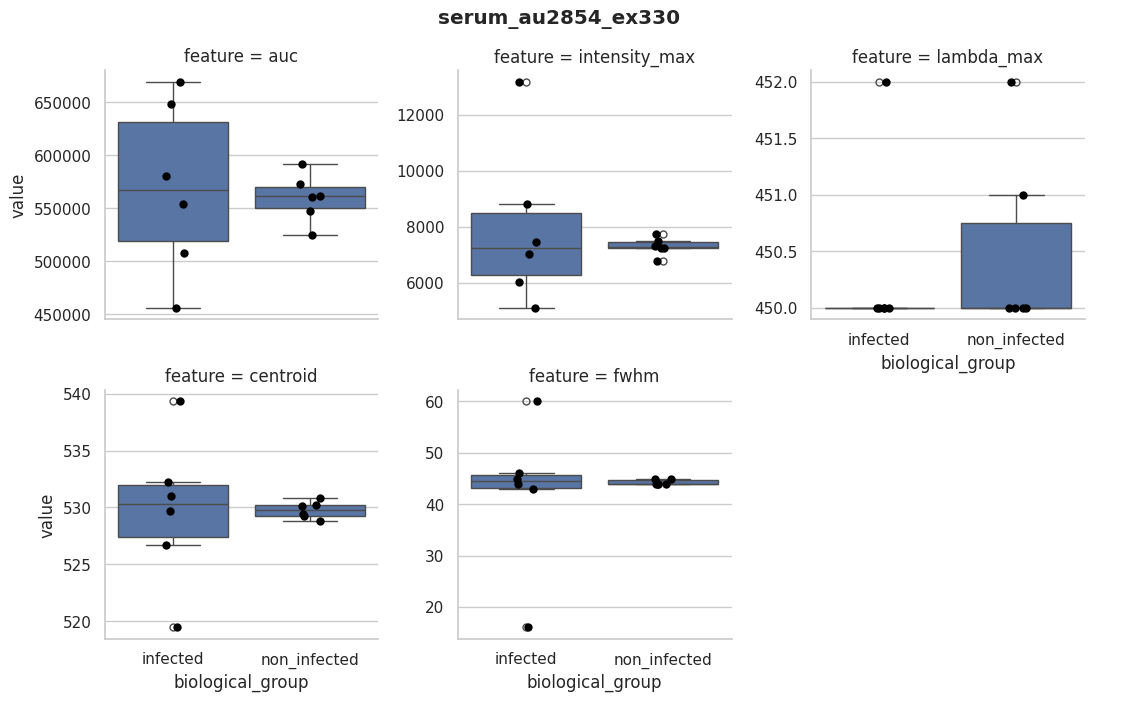

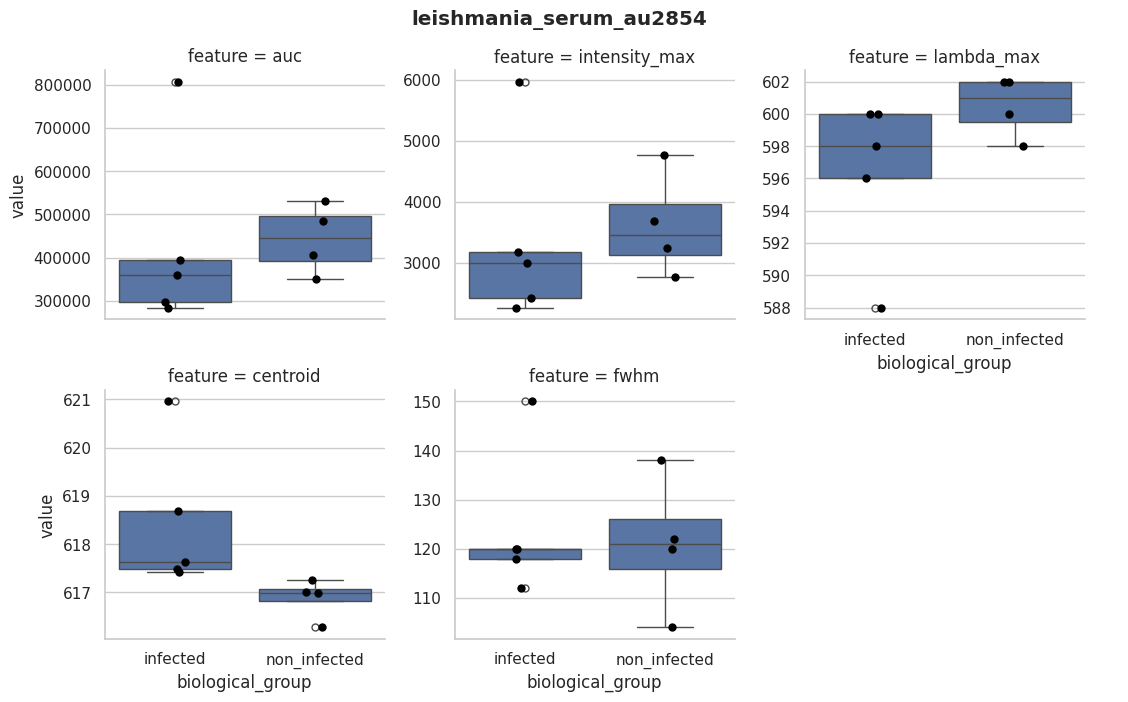

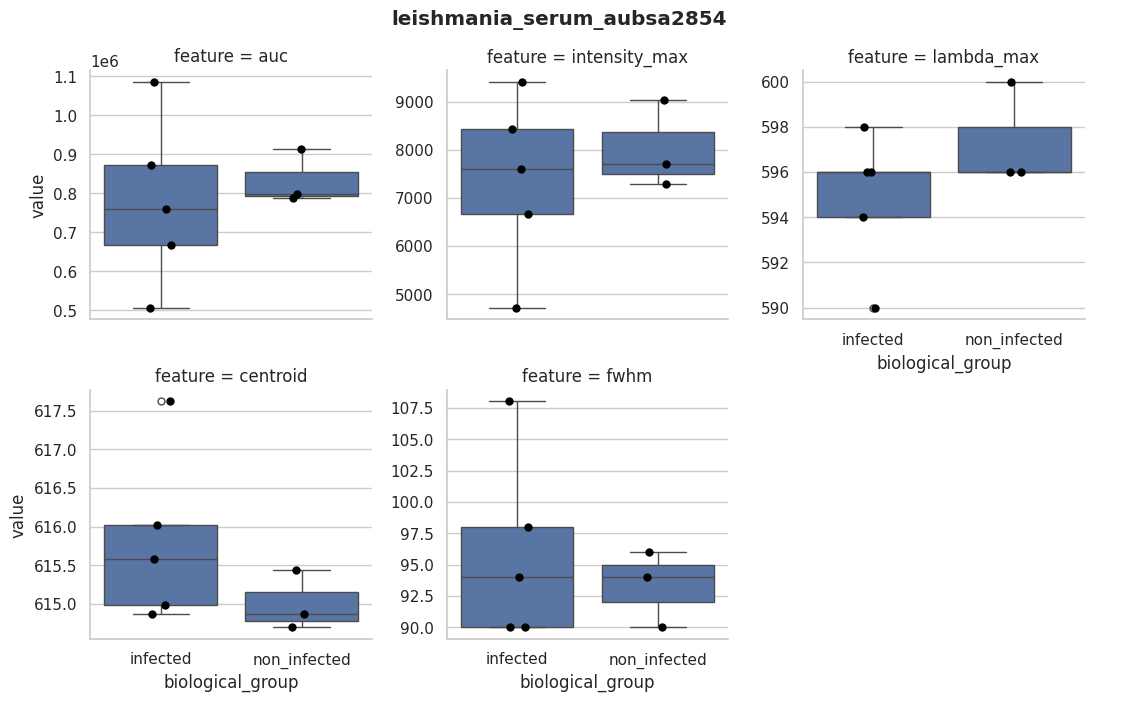

In [ ]:
for dataset in DATASETS:
    subset = features[features["dataset_id"] == dataset]
    long_features = subset.melt(
        id_vars=["biological_group"],
        value_vars=feature_columns,
        var_name="feature",
        value_name="value",
    )

    graph = sns.catplot(
        data=long_features,
        x="biological_group",
        y="value",
        col="feature",
        kind="box",
        col_wrap=3,
        sharey=False,
        height=3.4,
        aspect=1.1,
    )
    graph.map_dataframe(
        sns.stripplot,
        x="biological_group",
        y="value",
        color="black",
        jitter=0.08,
        size=6,
    )
    graph.figure.suptitle(dataset, y=1.03, fontweight="bold")
    plt.show()


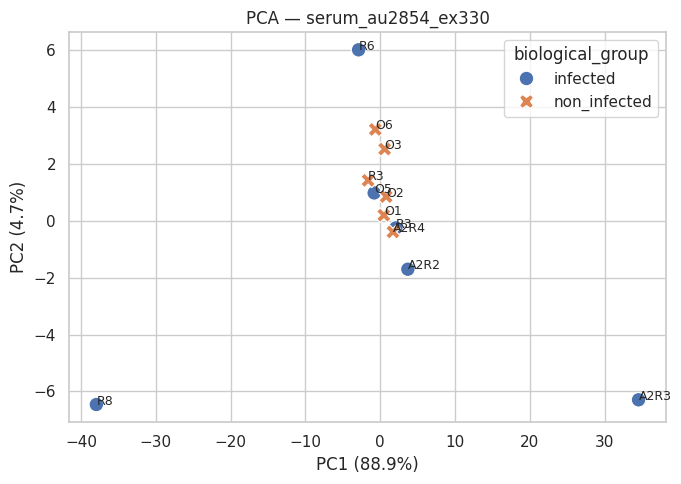

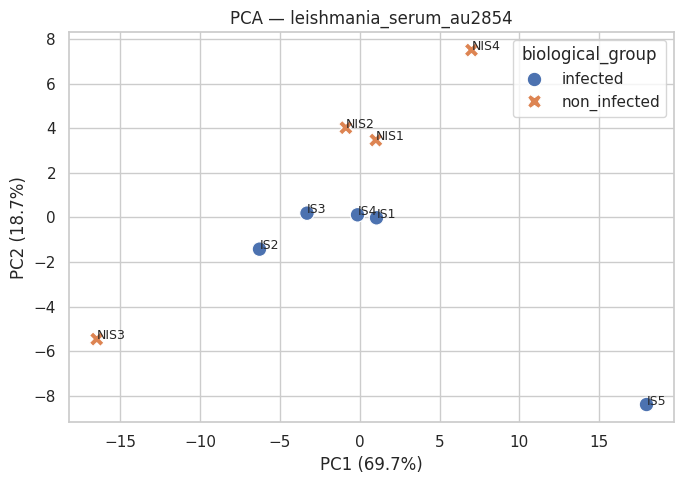

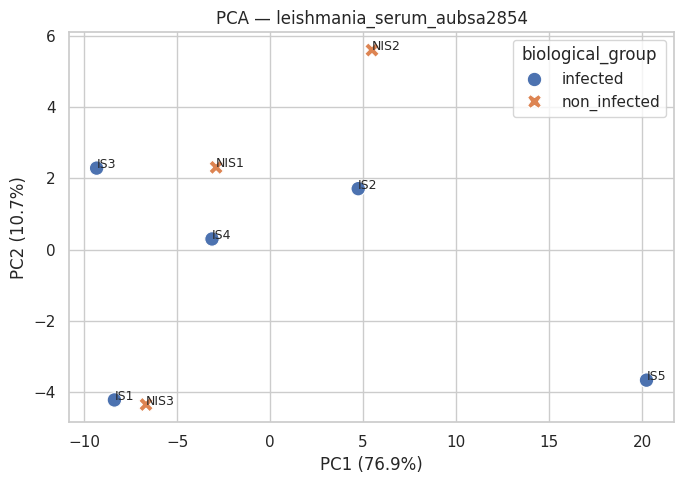

In [ ]:
def prepare_spectral_matrix(data, dataset_id, normalize_shape=True):
    subset = data[data["dataset_id"] == dataset_id].copy()
    matrix = subset.pivot_table(
        index=["biological_sample", "biological_group", "sample_id"],
        columns="emission_nm",
        values="intensity",
        aggfunc="mean",
    )
    matrix = matrix.dropna(axis=1)

    if normalize_shape:
        row_maximum = matrix.abs().max(axis=1).replace(0, np.nan)
        matrix = matrix.div(row_maximum, axis=0).dropna()

    metadata = matrix.index.to_frame(index=False)
    matrix.index = metadata["biological_sample"]
    return matrix, metadata


pca_results = {}

for dataset in DATASETS:
    X, metadata = prepare_spectral_matrix(
        biological_spectra, dataset, normalize_shape=True
    )

    scaled = StandardScaler().fit_transform(X)
    pca = PCA(n_components=min(2, len(X), X.shape[1]))
    scores = pca.fit_transform(scaled)

    pca_frame = metadata.copy()
    pca_frame["PC1"] = scores[:, 0]
    pca_frame["PC2"] = scores[:, 1] if scores.shape[1] > 1 else 0
    pca_results[dataset] = pca_frame

    plt.figure(figsize=(7, 5))
    sns.scatterplot(
        data=pca_frame,
        x="PC1",
        y="PC2",
        hue="biological_group",
        style="biological_group",
        s=110,
    )
    for _, row in pca_frame.iterrows():
        plt.text(row["PC1"], row["PC2"], row["sample_id"], fontsize=9)
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}%)")
    pc2_variance = pca.explained_variance_ratio_[1] if len(
        pca.explained_variance_ratio_
    ) > 1 else 0
    plt.ylabel(f"PC2 ({pc2_variance * 100:.1f}%)")
    plt.title(f"PCA — {dataset}")
    plt.tight_layout()
    plt.show()


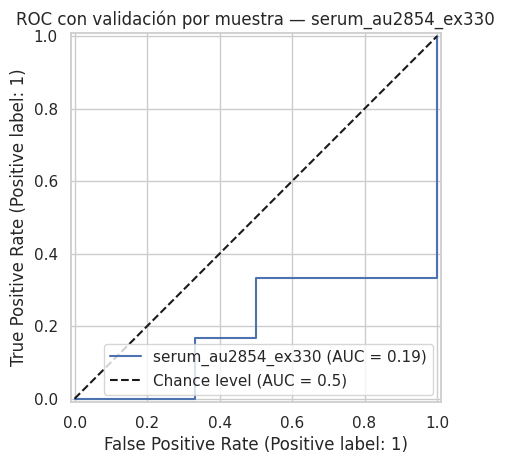

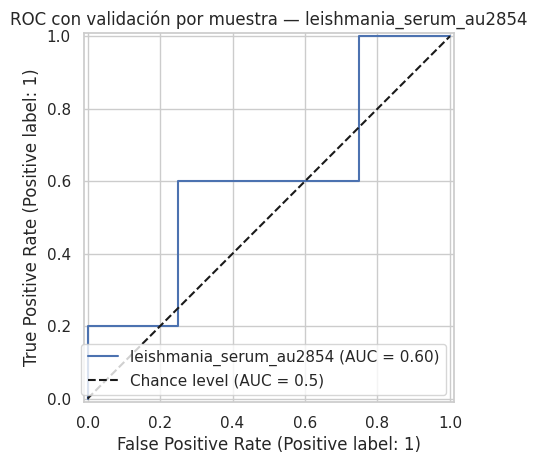

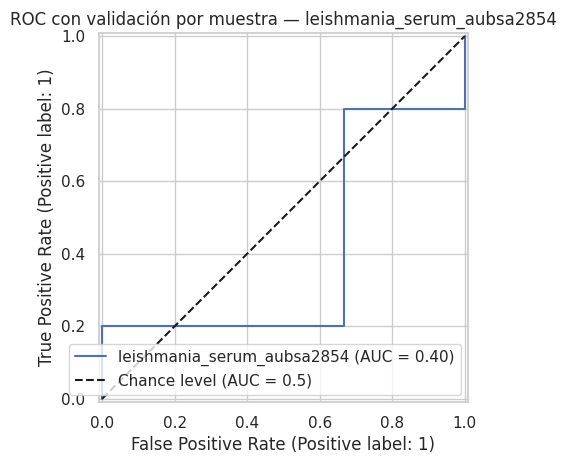

,dataset_id,n_biological_samples,roc_auc,balanced_accuracy,sensitivity,specificity,tn,fp,fn,tp
0,serum_au2854_ex330,12,0.194444,0.333333,0.166667,0.500000,3,3,5,1
1,leishmania_serum_au2854,9,0.600000,0.425000,0.600000,0.250000,1,3,2,3
2,leishmania_serum_aubsa2854,8,0.400000,0.566667,0.800000,0.333333,1,2,1,4


In [ ]:
classification_results = []

for dataset in DATASETS:
    X, metadata = prepare_spectral_matrix(
        biological_spectra, dataset, normalize_shape=True
    )
    y = (metadata["biological_group"] == "infected").astype(int).to_numpy()
    groups = metadata["biological_sample"].to_numpy()

    if len(np.unique(y)) < 2:
        continue

    model = Pipeline(
        [
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=0.95, svd_solver="full")),
            (
                "classifier",
                LogisticRegression(
                    class_weight="balanced",
                    max_iter=5000,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )

    logo = LeaveOneGroupOut()
    probabilities = cross_val_predict(
        model,
        X,
        y,
        groups=groups,
        cv=logo,
        method="predict_proba",
    )[:, 1]
    predictions = (probabilities >= 0.5).astype(int)

    tn, fp, fn, tp = confusion_matrix(y, predictions, labels=[0, 1]).ravel()
    roc_auc = roc_auc_score(y, probabilities)
    balanced_accuracy = balanced_accuracy_score(y, predictions)
    sensitivity = tp / (tp + fn) if tp + fn else np.nan
    specificity = tn / (tn + fp) if tn + fp else np.nan

    classification_results.append(
        {
            "dataset_id": dataset,
            "n_biological_samples": len(y),
            "roc_auc": roc_auc,
            "balanced_accuracy": balanced_accuracy,
            "sensitivity": sensitivity,
            "specificity": specificity,
            "tn": tn,
            "fp": fp,
            "fn": fn,
            "tp": tp,
        }
    )

    RocCurveDisplay.from_predictions(
        y,
        probabilities,
        name=dataset,
        plot_chance_level=True,
    )
    plt.title(f"ROC con validación por muestra — {dataset}")
    plt.show()

classification = pd.DataFrame(classification_results)
display(classification)


In [ ]:
features.to_csv("01_caracteristicas_espectrales.csv", index=False)
stats.to_csv("01_comparaciones_infectados_no_infectados.csv", index=False)
classification.to_csv("01_clasificacion_exploratoria.csv", index=False)

print("Archivos creados:")
print("- 01_caracteristicas_espectrales.csv")
print("- 01_comparaciones_infectados_no_infectados.csv")
print("- 01_clasificacion_exploratoria.csv")


Archivos creados:
- 01_caracteristicas_espectrales.csv
- 01_comparaciones_infectados_no_infectados.csv
- 01_clasificacion_exploratoria.csv
